In [23]:
import pandas as pd
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [24]:
data = pd.read_excel('Luas Panen, Produksi, dan Produktivitas Padi Menurut Provinsi, 2023.xlsx')
data.head()

,38 Provinsi,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,"Luas Panen, Produksi, dan Produktivitas Padi M...",NaN,NaN
1,NaN,Luas Panen (ha),Produktivitas (ku/ha),Produksi (ton)
2,NaN,2023,2023,2023
3,ACEH,254287.38,55.22,1404234.82
4,SUMATERA UTARA,406109.49,51.4,2087474.15


In [25]:
data = data.iloc[3:]
data.head()

,38 Provinsi,Unnamed: 1,Unnamed: 2,Unnamed: 3
3,ACEH,254287.38,55.22,1404234.82
4,SUMATERA UTARA,406109.49,51.4,2087474.15
5,SUMATERA BARAT,300564.77,49.32,1482468.79
6,RIAU,51914.14,39.68,205972.55
7,JAMBI,61236.64,45.06,275941.45


In [26]:
data.columns = ['Provinsi', 'Luas Panen (ha)', 'Produktivitas (ku/ha)', 'Produksi (ton)']
data.head()

,Provinsi,Luas Panen (ha),Produktivitas (ku/ha),Produksi (ton)
3,ACEH,254287.38,55.22,1404234.82
4,SUMATERA UTARA,406109.49,51.4,2087474.15
5,SUMATERA BARAT,300564.77,49.32,1482468.79
6,RIAU,51914.14,39.68,205972.55
7,JAMBI,61236.64,45.06,275941.45


In [27]:
data.isnull().sum()

Provinsi                 0
Luas Panen (ha)          0
Produktivitas (ku/ha)    0
Produksi (ton)           0
dtype: int64

{'whiskers': [<matplotlib.lines.Line2D at 0x24c36e056a0>,
 'caps': [<matplotlib.lines.Line2D at 0x24c36e05940>,
 'boxes': [<matplotlib.lines.Line2D at 0x24c36e05550>],
 'medians': [<matplotlib.lines.Line2D at 0x24c36e05be0>],
 'fliers': [<matplotlib.lines.Line2D at 0x24c36e05d30>],
 'means': []}

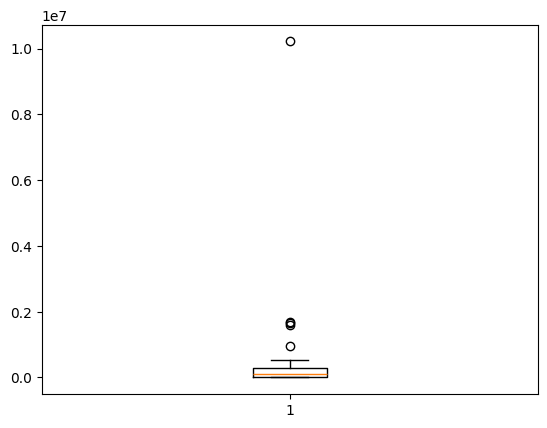

In [28]:
plt.boxplot(data['Luas Panen (ha)'])

{'whiskers': [<matplotlib.lines.Line2D at 0x24c36ebcc20>,
 'caps': [<matplotlib.lines.Line2D at 0x24c36ebcec0>,
 'boxes': [<matplotlib.lines.Line2D at 0x24c36ebcad0>],
 'medians': [<matplotlib.lines.Line2D at 0x24c36ebd160>],
 'fliers': [<matplotlib.lines.Line2D at 0x24c36ebd2b0>],
 'means': []}

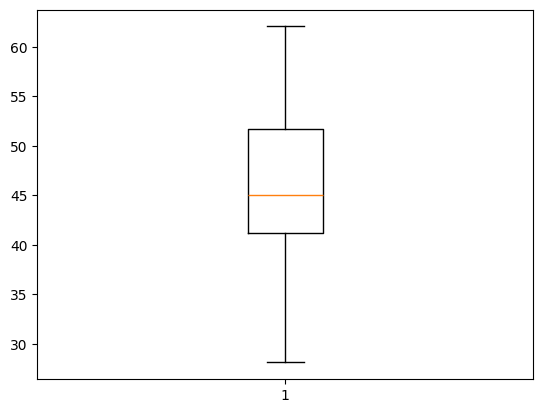

In [29]:
plt.boxplot(data['Produktivitas (ku/ha)'])

{'whiskers': [<matplotlib.lines.Line2D at 0x24c36f30590>,
 'caps': [<matplotlib.lines.Line2D at 0x24c36f30830>,
 'boxes': [<matplotlib.lines.Line2D at 0x24c36f30440>],
 'medians': [<matplotlib.lines.Line2D at 0x24c36f30ad0>],
 'fliers': [<matplotlib.lines.Line2D at 0x24c36f30c20>],
 'means': []}

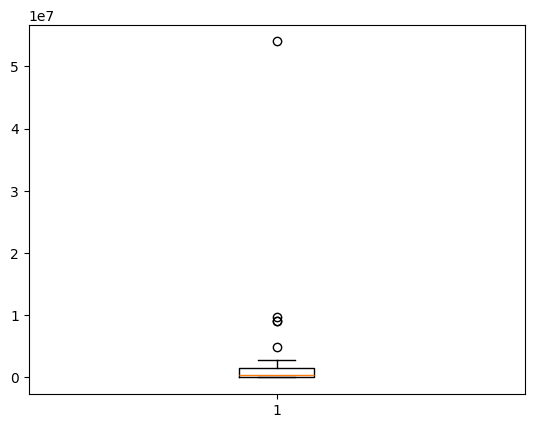

In [30]:
plt.boxplot(data['Produksi (ton)'])

In [31]:
data.tail()

,Provinsi,Luas Panen (ha),Produktivitas (ku/ha),Produksi (ton)
37,PAPUA,840.18,44.76,3760.45
38,PAPUA SELATAN,44807.86,40.98,183627.83
39,PAPUA TENGAH,2094.2,44.28,9273.22
40,PAPUA PEGUNUNGAN,14.14,43.59,61.63
41,INDONESIA,10213705.17,52.85,53980993.19


In [32]:
data = data.iloc[:-1].reset_index(drop=True)
data.tail()

,Provinsi,Luas Panen (ha),Produktivitas (ku/ha),Produksi (ton)
33,PAPUA BARAT DAYA,579.83,41.34,2396.95
34,PAPUA,840.18,44.76,3760.45
35,PAPUA SELATAN,44807.86,40.98,183627.83
36,PAPUA TENGAH,2094.2,44.28,9273.22
37,PAPUA PEGUNUNGAN,14.14,43.59,61.63


In [33]:
data

,Provinsi,Luas Panen (ha),Produktivitas (ku/ha),Produksi (ton)
0,ACEH,254287.38,55.22,1404234.82
1,SUMATERA UTARA,406109.49,51.4,2087474.15
2,SUMATERA BARAT,300564.77,49.32,1482468.79
3,RIAU,51914.14,39.68,205972.55
4,JAMBI,61236.64,45.06,275941.45
5,SUMATERA SELATAN,504143.03,56.19,2832773.92
6,BENGKULU,57877.18,49.53,286684.43
7,LAMPUNG,530108.09,52.03,2757898.19
8,KEP. BANGKA BELITUNG,15284.56,43.49,66468.89
9,KEP. RIAU,115.27,28.11,324.01


In [34]:
fig = plt.figure()
ax = plt.axes(projection = '3d')

x1 = data['Luas Panen (ha)']
x2 = data['Produktivitas (ku/ha)']
y = data['Produksi (ton)']

ax.scatter3D(x1, x2, y)
plt.show()

AttributeError: 'float' object has no attribute 'view'

<Figure size 640x480 with 1 Axes>

In [35]:
X = data[['Luas Panen (ha)', 'Produktivitas (ku/ha)']]
X.head()

,Luas Panen (ha),Produktivitas (ku/ha)
0,254287.38,55.22
1,406109.49,51.4
2,300564.77,49.32
3,51914.14,39.68
4,61236.64,45.06


In [36]:
y = data['Produksi (ton)']
y.head()

0    1404234.82
1    2087474.15
2    1482468.79
3     205972.55
4     275941.45
Name: Produksi (ton), dtype: object

In [37]:
from sklearn import linear_model

regr = linear_model.LinearRegression()
regr.fit(X, y)
print(regr.coef_)
print(regr.intercept_)

[5.56836114e+00 7.49231789e+03]
-420125.065542602


In [38]:
y_pred = regr.predict([[254287.38, 55.22]])
print(y_pred)

[1409564.6935764]


C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [39]:
y_pred = regr.predict([[101580.3, 32.56]])
print(y_pred)

[389460.60010223]


C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
